In [ ]:
import sys
sys.path.append("../../")

In [1]:
# imports
import pandas as pd
import tensorflow as tf
# utilities
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

from utils import visualization as viz
from utils.processing import filter_rsos_by_min_state_count, rso_train_test_split, assemble_scaled_state_df

RANDOM_STATE=209
PADDING_VALUE=-999.0 # <-- -999.0 never appears in our data, safe to use as the padding token

2025-05-07 08:42:05.806175: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-07 08:42:05.806226: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-07 08:42:05.806884: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-07 08:42:05.811735: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Separate features into different categories
X_numerical = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER'] 
X_numerical_revised = X_numerical + ['MEAN_MOTION_2ND_DER', 'B_STAR']
X_features_to_use = X_numerical_revised
response = 'TYPE'

df_final = pd.read_csv('../data/large/final_df_v1.csv') # <-- Run Part 1 of DataConsolidation.ipynb to produce file
df_final = df_final.sort_values(by=['NUMBER', 'EPOCH'])
df_final.reset_index(inplace=True, drop=True)

### Reshape data & pad the objects

In [3]:
# Scale state data
# scaler = StandardScaler()
# df_scaled = df_final.copy()
# df_scaled[X_features_to_use] = scaler.fit_transform(df_final[X_features_to_use])

In [4]:
# Get maximum number of states for all objects
MAX_STATE_COUNT = df_final['NUMBER'].value_counts().max()
N_FEATURES = len(X_features_to_use)

# Group by objects
grouped = df_final.groupby('NUMBER')

X_padded = []
y_labels = []

# Iterate through objects and pad
for number, group in grouped:

    # Pad states
    states = group[X_features_to_use].values.astype(np.float32)
    padded = tf.keras.preprocessing.sequence.pad_sequences(
        [states], maxlen=MAX_STATE_COUNT, dtype='float32',
        padding='post', truncating='post', value=PADDING_VALUE
    )
    X_padded.append(padded[0])

    # Assign label
    label = group[response].iloc[0]
    y_labels.append(label)

X_array = np.array(X_padded).astype(np.float32)
y_array = np.array(y_labels)

print(f'X shape: {X_array.shape}')
print(f'y shape: {y_array.shape}')

X shape: (30495, 49, 11)
y shape: (30495,)


### Encode labels

In [5]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_array).astype(np.int32)

### Fit the scaler

In [6]:
X_array_flat = X_array.reshape(-1, N_FEATURES)
valid_mask = ~(X_array_flat == PADDING_VALUE).all(axis=1)
X_array_flat_valid = X_array_flat[valid_mask]

scaler = StandardScaler()
scaler.fit(X_array_flat_valid)

StandardScaler()

### Split to train and test

In [7]:
X_temp, X_test, y_temp, y_test = train_test_split(X_array, y_encoded, test_size=0.15, random_state=RANDOM_STATE, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=RANDOM_STATE, stratify=y_temp)

### Upsample with SMOTE

In [8]:
# Flatten X_train for pre-training the state model
X_train_flat = X_train.reshape(-1, N_FEATURES)
train_mask = ~(X_train_flat == PADDING_VALUE ).all(axis=1)  
X_train_flat_valid = X_train_flat[train_mask]

# Repeat the flat y_train for the state model
y_train_flat_valid = np.repeat(y_train, MAX_STATE_COUNT)[train_mask]

# Flatten X_val for validating the state model
X_val_flat = X_val.reshape(-1, N_FEATURES)
val_mask = ~(X_val_flat == PADDING_VALUE ).all(axis=1)  
X_val_flat_valid = X_val_flat[val_mask]

# Repeat the flat y_val for the state model
y_val_flat_valid = np.repeat(y_val, MAX_STATE_COUNT)[val_mask]

In [9]:
# Upsample training data to pre-train the state model
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res_raw, y_train_res = smote.fit_resample(X_train_flat_valid, y_train_flat_valid)
print(f'Class counts:{np.bincount(y_train_res)}')

Class counts:[395624 395624 395624]


### Scale the data

In [10]:
X_train_scaled = scaler.transform(X_train_res_raw)
X_val_scaled = scaler.transform(X_val_flat_valid)

### Pre-train the state model

In [11]:
# Training parameters
EPOCHS = 50
BATCH_SIZE = 64
LR = 0.001

# Define state model
DROPOUT = 0.3
state_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_FEATURES,)),
    tf.keras.layers.Dense(512),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(256),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(128),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(3, activation='softmax'),
])

state_model.summary()

state_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'],
)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

state_model_history = state_model.fit(
    X_train_scaled, y_train_res,
    validation_data=[X_val_scaled, y_val_flat_valid],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)
state_history = state_model_history.history

state_model.save_weights('models/state_model.weights.h5')

2025-05-07 08:42:39.416759: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3e:00.0, compute capability: 8.9


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               6144      
                                                                 
 layer_normalization (Layer  (None, 512)               1024      
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 512)               0         
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 layer_normalization_1 (Lay  (None, 256)               512       
 erNormalization)                                       

2025-05-07 08:42:40.763359: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-05-07 08:42:41.357472: I external/local_xla/xla/service/service.cc:168] XLA service 0x152f0d2d8eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-07 08:42:41.357519: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2025-05-07 08:42:41.361839: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746621761.435609   28914 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18545/18545 [==============================] - 58s 3ms/step - loss: 0.4472 - accuracy: 0.8198 - val_loss: 0.4068 - val_accuracy: 0.8296
Epoch 2/50
18545/18545 [==============================] - 56s 3ms/step - loss: 0.3807 - accuracy: 0.8503 - val_loss: 0.3385 - val_accuracy: 0.8585
Epoch 3/50
18545/18545 [==============================] - 56s 3ms/step - loss: 0.3603 - accuracy: 0.8590 - val_loss: 0.3610 - val_accuracy: 0.8509
Epoch 4/50
18545/18545 [==============================] - 56s 3ms/step - loss: 0.3484 - accuracy: 0.8647 - val_loss: 0.3282 - val_accuracy: 0.8648
Epoch 5/50
18545/18545 [==============================] - 56s 3ms/step - loss: 0.3402 - accuracy: 0.8681 - val_loss: 0.3306 - val_accuracy: 0.8682
Epoch 6/50
18545/18545 [==============================] - 56s 3ms/step - loss: 0.3337 - accuracy: 0.8710 - val_loss: 0.3209 - val_accuracy: 0.8713
Epoch 7/50
18545/18545 [==============================] - 56s 3ms/step - loss: 0.3281 - accuracy: 0.8731 - val_loss: 0.3277 - val

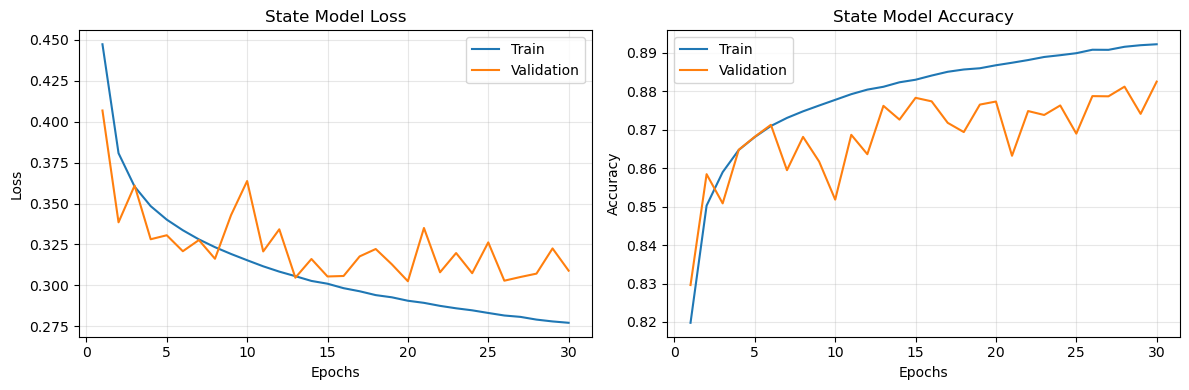

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
for i, metric in enumerate(['loss', 'accuracy']):
    for k, split in enumerate(['', 'val_']):
        data = state_history[f'{split}{metric}']
        axes[i].plot(np.arange(len(data))+1, data, color=f'C{k}', label='Train' if split == '' else 'Validation')
        axes[i].legend()
        axes[i].set_xlabel('Epochs')
        axes[i].set_ylabel(metric.title())
        axes[i].set_title(f'State Model {metric.title()}')
        axes[i].grid(alpha=0.3)

plt.tight_layout()

### Freeze the state model and train the object model only

In [13]:
state_model.trainable = False

In [14]:
# Scale the 3D tensors
X_train_scaled_flat = X_train_flat.copy()
X_train_scaled_flat[train_mask] = scaler.transform(X_train_flat[train_mask])
X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)

X_val_scaled_flat = X_val_flat.copy()
X_val_scaled_flat[val_mask] = scaler.transform(X_val_flat[val_mask])
X_val_scaled = X_val_scaled_flat.reshape(X_val.shape)

X_test_flat = X_test.reshape(-1, N_FEATURES)
test_mask = ~(X_test_flat == PADDING_VALUE).all(axis=1)
X_test_scaled_flat = X_test_flat.copy()
X_test_scaled_flat[test_mask] = scaler.transform(X_test_flat[test_mask])
X_test_scaled = X_test_scaled_flat.reshape(X_test.shape)

In [15]:
# Repeat the train y's for the state model only
y_train_repeated = np.repeat(np.expand_dims(y_train, axis=-1), MAX_STATE_COUNT, axis=-1).astype(np.int32)
y_val_repeated = np.repeat(np.expand_dims(y_val, axis=-1), MAX_STATE_COUNT, axis=-1).astype(np.int32)

In [16]:
# Training parameters
EPOCHS = 50
BATCH_SIZE = 32
LR = 0.0001

# Input is a tensor of shape (BATCH_SIZE, MAX_STATE_COUNT, N_FEATURES
input = tf.keras.layers.Input(shape=(MAX_STATE_COUNT, N_FEATURES))

# Values of -999.0 are ignored
x = tf.keras.layers.Masking(mask_value=PADDING_VALUE)(input)

# Pass each state independently into the state_model, save output as 'state_output'
state_output = tf.keras.layers.TimeDistributed(state_model, name='state_output')(x)

# LSTM with 128 units
# x = tf.keras.layers.LSTM(128)(state_output)

# Multihead Attention
# x = tf.keras.layers.MultiHeadAttention(
#     num_heads=8,
#     key_dim=128,
#     dropout=0.,
# )(query=state_output, value=state_output)
# x = tf.keras.layers.GlobalAveragePooling1D()(x)

# Feedforward neural network as the object_model
DROPOUT = 0.3
x = tf.keras.layers.Flatten()(state_output)
x = tf.keras.layers.Dense(512)(x)
x = tf.keras.layers.LayerNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
x = tf.keras.layers.Dense(256)(x)
x = tf.keras.layers.LayerNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.LayerNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
x = tf.keras.layers.Dense(64)(x)
x = tf.keras.layers.LayerNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)

# Save the output of the object model as 'object_output'
object_output = tf.keras.layers.Dense(3, activation='softmax', name='object_output')(x)

object_model = tf.keras.Model(inputs=input, outputs=[state_output, object_output], name='object_model')
object_model.summary()

object_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR), 
    loss={'state_output': 'sparse_categorical_crossentropy', 'object_output': 'sparse_categorical_crossentropy'}, 
    loss_weights={'state_output': 1, 'object_output': 3}, # More emphasis on getting final object prediction right
    weighted_metrics={'state_output': 'accuracy', 'object_output': 'accuracy'},
)

# Create mask for the loss function so padded values don't contribute to the loss
mask = (X_train != PADDING_VALUE).any(axis=-1)
state_sample_weights = mask.astype(np.float32)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_object_output_loss', patience=10, restore_best_weights=True, verbose=1)

object_model_history = object_model.fit(
    X_train_scaled,
    {'state_output': y_train_repeated, 'object_output': y_train},
    sample_weight={'state_output':state_sample_weights, 'object_output': np.ones(len(y_train))},
    validation_data=[X_val_scaled, {'state_output': y_val_repeated, 'object_output': y_val}],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)
object_history = object_model_history.history

object_model.save_weights('models/object_model.weights.h5')

Model: "object_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 49, 11)]          0         
                                                                 
 masking (Masking)           (None, 49, 11)            0         
                                                                 
 state_output (TimeDistribu  (None, 49, 3)             172547    
 ted)                                                            
                                                                 
 flatten (Flatten)           (None, 147)               0         
                                                                 
 dense_4 (Dense)             (None, 512)               75776     
                                                                 
 layer_normalization_3 (Lay  (None, 512)               1024      
 erNormalization)                                     

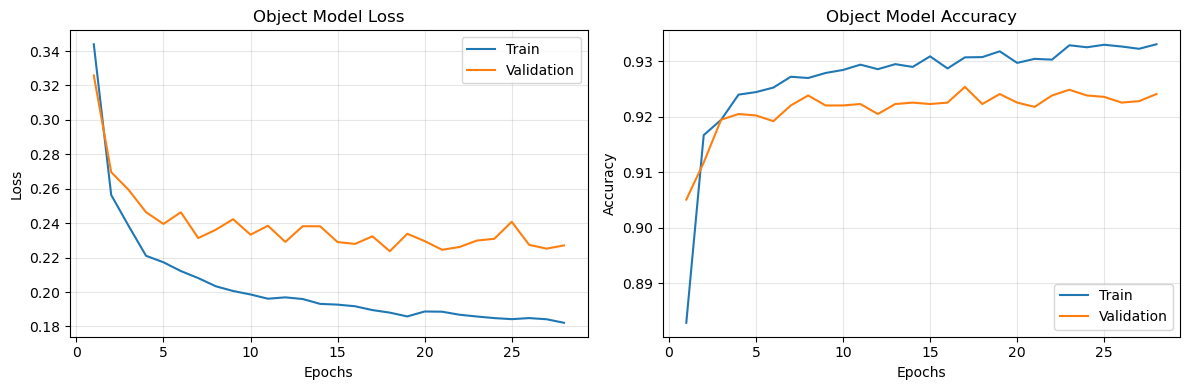

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
for i, metric in enumerate(['loss', 'accuracy']):
    for k, split in enumerate(['', 'val_']):
        data = object_history[f'{split}object_output_{metric}']
        axes[i].plot(np.arange(len(data))+1, data, color=f'C{k}', label='Train' if split == '' else 'Validation')
        axes[i].legend()
        axes[i].set_xlabel('Epochs')
        axes[i].set_ylabel(metric.title())
        axes[i].set_title(f'Object Model {metric.title()}')
        axes[i].grid(alpha=0.3)

plt.tight_layout()

### Tune everything

In [18]:
# Training parameters
EPOCHS = 50
BATCH_SIZE = 32
LR = 0.00001

# Tune everything
state_model.trainable = True

object_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR), 
    loss={'state_output': 'sparse_categorical_crossentropy', 'object_output': 'sparse_categorical_crossentropy'}, 
    loss_weights={'state_output': 1, 'object_output': 3}, # More emphasis on getting final object prediction right
    weighted_metrics={'state_output': 'accuracy', 'object_output': 'accuracy'},
)

object_model.summary()

# Create mask for the loss function so padded values don't contribute to the loss
mask = (X_train != PADDING_VALUE).any(axis=-1)
state_sample_weights = mask.astype(np.float32)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_object_output_loss', patience=10, restore_best_weights=True, verbose=1)

final_model_history = object_model.fit(
    X_train_scaled,
    {'state_output': y_train_repeated, 'object_output': y_train},
    sample_weight={'state_output':state_sample_weights, 'object_output': np.ones(len(y_train))},
    validation_data=[X_val_scaled, {'state_output': y_val_repeated, 'object_output': y_val}],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)
final_history = final_model_history.history

object_model.save_weights('models/final_model.weights.h5')

Model: "object_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 49, 11)]          0         
                                                                 
 masking (Masking)           (None, 49, 11)            0         
                                                                 
 state_output (TimeDistribu  (None, 49, 3)             172547    
 ted)                                                            
                                                                 
 flatten (Flatten)           (None, 147)               0         
                                                                 
 dense_4 (Dense)             (None, 512)               75776     
                                                                 
 layer_normalization_3 (Lay  (None, 512)               1024      
 erNormalization)                                     

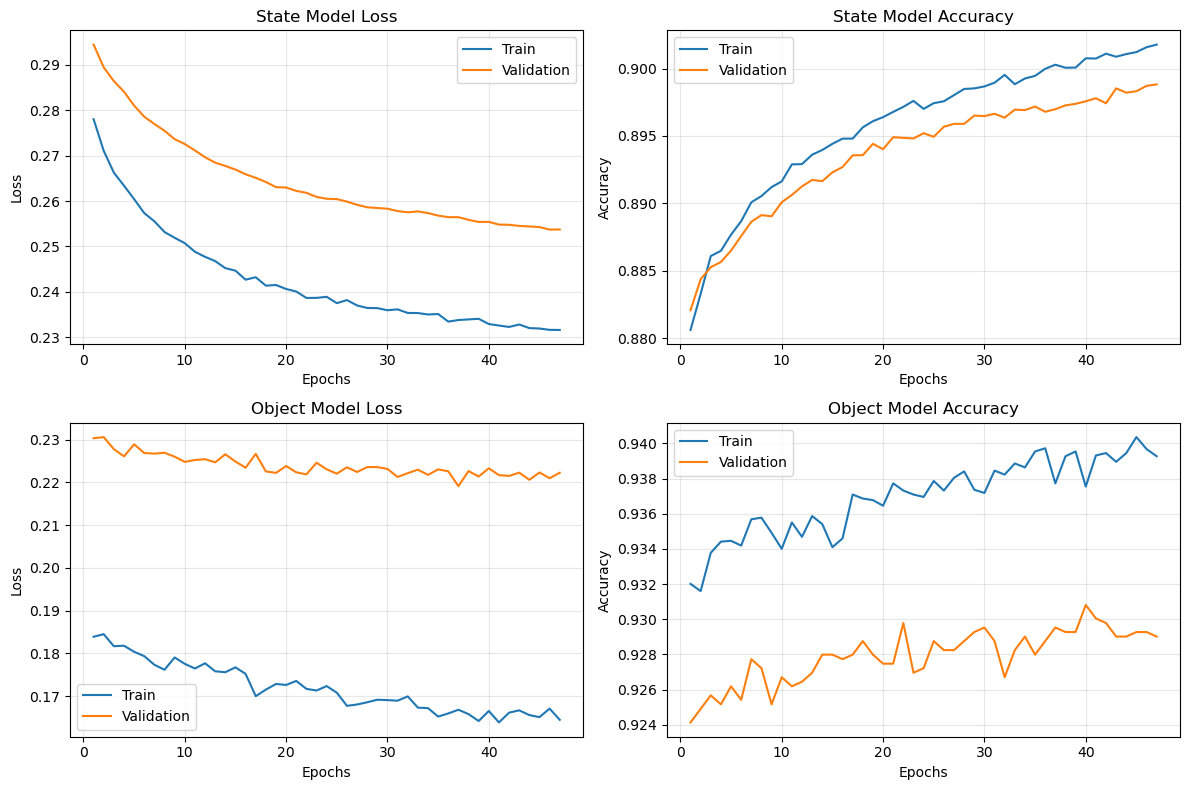

In [19]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
for i, level in enumerate(['state', 'object']):
    for j, metric in enumerate(['loss', 'accuracy']):
        for k, split in enumerate(['', 'val_']):
            data = final_history[f'{split}{level}_output_{metric}']
            axes[i][j].plot(np.arange(len(data))+1, data, color=f'C{k}', label='Train' if split == '' else 'Validation')
            axes[i][j].legend()
            axes[i][j].set_xlabel('Epochs')
            axes[i][j].set_ylabel(metric.title())
            axes[i][j].set_title(f'{level.title()} Model {metric.title()}')
            axes[i][j].grid(alpha=0.3)

plt.tight_layout()

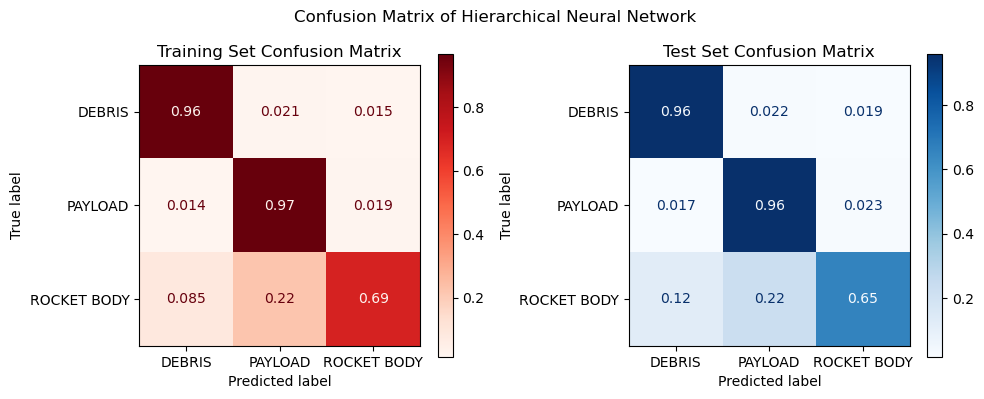

In [20]:
y_train_pred = np.argmax(object_model.predict(X_train_scaled, verbose=0)[1], axis=-1)
y_test_pred = np.argmax(object_model.predict(X_test_scaled, verbose=0)[1], axis=-1)
viz.plot_side_my_side_confusion("Confusion Matrix of Hierarchical Neural Network", y_train, y_train_pred, "Training Set Confusion Matrix", y_test, y_test_pred, "Test Set Confusion Matrix", label_encoder)

In [21]:
train_loss, train_state_loss, train_object_loss, train_state_acc, train_object_acc = object_model.evaluate(X_train_scaled, [y_train_repeated, y_train])
y_test_repeated = np.repeat(np.expand_dims(y_test, axis=-1), MAX_STATE_COUNT, axis=-1).astype(np.int32)
test_loss, test_state_loss, test_object_loss, test_state_acc, test_object_acc = object_model.evaluate(X_test_scaled, [y_test_repeated, y_test])

143/143 [==============================] - 0s 3ms/step - loss: 0.8521 - state_output_loss: 0.2557 - object_output_loss: 0.1988 - state_output_accuracy: 0.9002 - object_output_accuracy: 0.9360


In [22]:
print('===== TRAIN =====')
print(f'Object Accuracy: {train_object_acc:.2%}')
print(f'Object Loss: {train_object_loss:.5f}')
print(f'State Accuracy: {train_state_acc:.2%}')
print(f'State Loss: {train_state_loss:.5f}')
print(f'Aggregate Loss: {train_loss:.5f}')
print('\n===== TEST =====')
print(f'Object Accuracy: {test_object_acc:.2%}')
print(f'Object Loss: {test_object_loss:.5f}')
print(f'State Accuracy: {test_state_acc:.2%}')
print(f'State Loss: {test_state_loss:.5f}')
print(f'Aggregate Loss: {test_loss:.5f}')

===== TRAIN =====
Object Accuracy: 94.48%
Object Loss: 0.14749
State Accuracy: 91.08%
State Loss: 0.20531
Aggregate Loss: 0.64776

===== TEST =====
Object Accuracy: 93.60%
Object Loss: 0.19879
State Accuracy: 90.02%
State Loss: 0.25573
Aggregate Loss: 0.85210
